<a href="https://colab.research.google.com/github/zkalykov/Fraud-Detection-Transactions-Dataset/blob/main/Synthetic_Financial_Datasets_For_Fraud_Detection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install kagglehub

In [ ]:
!ls

sample_data


In [ ]:
!rm -r sample_data/ && rmdir sample_data

rmdir: failed to remove 'sample_data': No such file or directory



##Synthetic Financial Datasets For Fraud Detection

https://www.kaggle.com/datasets/ealaxi/paysim1?select=PS_20174392719_1491204439457_log.csv



In [ ]:
import os
import shutil
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")
destination = "/content"

if not os.path.exists(destination):
    os.makedirs(destination)

print("Copying files to current workspace...")
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    dest_file = os.path.join(destination, filename)

    if filename.endswith('.csv'):
        try:
            shutil.copy(source_file, dest_file)
            print(f"✅ Successfully copied: {filename}")
        except PermissionError:
            print(f"❌ Could not copy {filename} due to system lock.")

print(f"\nDownloaded")

100%|██████████| 178M/178M [00:05<00:00, 36.9MB/s]

Extracting files...


Copying files to current workspace...
✅ Successfully copied: PS_20174392719_1491204439457_log.csv

Downloaded


In [ ]:
import pandas as pd

df_paysim = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')
print("\n--- First 5 rows of PaySim Dataset ---")
display(df_paysim.head())


--- First 5 rows of PaySim Dataset ---


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
def show_metrics(df, file_path, name):
    print(f"\n{'='*20} {name} {'='*20}")

    # 1. Rows and Columns
    rows, cols = df.shape

    # 2. Size calculations
    file_mb = os.path.getsize(file_path) / (1024 * 1024)
    ram_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

    # 3. Output
    print(f"Total Rows:      {rows:,}")
    print(f"Total Columns:   {cols}")
    print(f"Total Data:      {df.size:,} data points")
    print(f"Size on Disk:    {file_mb:.2f} MB")
    print(f"Size in RAM:     {ram_mb:.2f} MB")

# Overview
show_metrics(df_paysim, '/content/PS_20174392719_1491204439457_log.csv', "PaySim Dataset")


==================== PaySim Dataset ====================
Total Rows:      6,362,620
Total Columns:   11
Total Data:      69,988,820 data points
Size on Disk:    470.67 MB
Size in RAM:     1452.57 MB


In [ ]:
import psutil

ram = psutil.virtual_memory()

print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")
print(f"RAM Used: {ram.percent}%")

Total RAM: 176.88 GB
Available RAM: 172.71 GB
RAM Used: 2.4%


In [ ]:
files = {
    "PaySim Dataset": "/content/PS_20174392719_1491204439457_log.csv"
}

for name, path in files.items():
    df = pd.read_csv(path)
    print(f"\n{'='*30}\nDetailed Analysis: {name}\n{'='*30}")

    analysis_list = []

    for col in df.columns:
        sample_val = df[col].iloc[0]
        dtype = df[col].dtype

        if pd.api.types.is_numeric_dtype(df[col]):
            analysis = f"Range: {df[col].min()} to {df[col].max()}"
        else:
            analysis = f"{df[col].nunique()} unique categories"

        analysis_list.append({
            "Column Name": col,
            "Sample Value": sample_val,
            "Analysis / Range": analysis,
            "Data Type": dtype
        })

    summary_df = pd.DataFrame(analysis_list)
    display(summary_df)


Detailed Analysis: PaySim Dataset


,Column Name,Sample Value,Analysis / Range,Data Type
0,step,1,Range: 1 to 743,int64
1,type,PAYMENT,5 unique categories,object
2,amount,9839.64,Range: 0.0 to 92445516.64,float64
3,nameOrig,C1231006815,6353307 unique categories,object
4,oldbalanceOrg,170136.0,Range: 0.0 to 59585040.37,float64
5,newbalanceOrig,160296.36,Range: 0.0 to 49585040.37,float64
6,nameDest,M1979787155,2722362 unique categories,object
7,oldbalanceDest,0.0,Range: 0.0 to 356015889.35,float64
8,newbalanceDest,0.0,Range: 0.0 to 356179278.92,float64
9,isFraud,0,Range: 0 to 1,int64


In [ ]:
df_paysim_clean = df_paysim.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

paysim_data = pd.concat([df_paysim_clean], ignore_index=True)

display(paysim_data[:20])

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,0


In [ ]:
column_summary = []

for col in paysim_data.columns:
    column_summary.append({
        "Column Name": col,
        "Data Type": paysim_data[col].dtype,
        "Non-Null Count": paysim_data[col].count(),
        "Missing Values (%)": f"{(paysim_data[col].isna().sum() / len(paysim_data) * 100):.2f}%",
        "Unique Values": paysim_data[col].nunique(),
        "Sample Value": paysim_data[col].dropna().iloc[0] if not paysim_data[col].dropna().empty else "All Null"
    })

# Convert to DataFrame for a clean "column-like" display
df_summary = pd.DataFrame(column_summary)

print(f"--- Final Dataset Column Analysis ({paysim_data.shape[0]} rows) ---")
display(df_summary)

--- Final Dataset Column Analysis (6362620 rows) ---


,Column Name,Data Type,Non-Null Count,Missing Values (%),Unique Values,Sample Value
0,step,int64,6362620,0.00%,743,1
1,type,object,6362620,0.00%,5,PAYMENT
2,amount,float64,6362620,0.00%,5316900,9839.64
3,oldbalanceOrg,float64,6362620,0.00%,1845844,170136.0
4,newbalanceOrig,float64,6362620,0.00%,2682586,160296.36
5,oldbalanceDest,float64,6362620,0.00%,3614697,0.0
6,newbalanceDest,float64,6362620,0.00%,3555499,0.0
7,isFraud,int64,6362620,0.00%,2,0


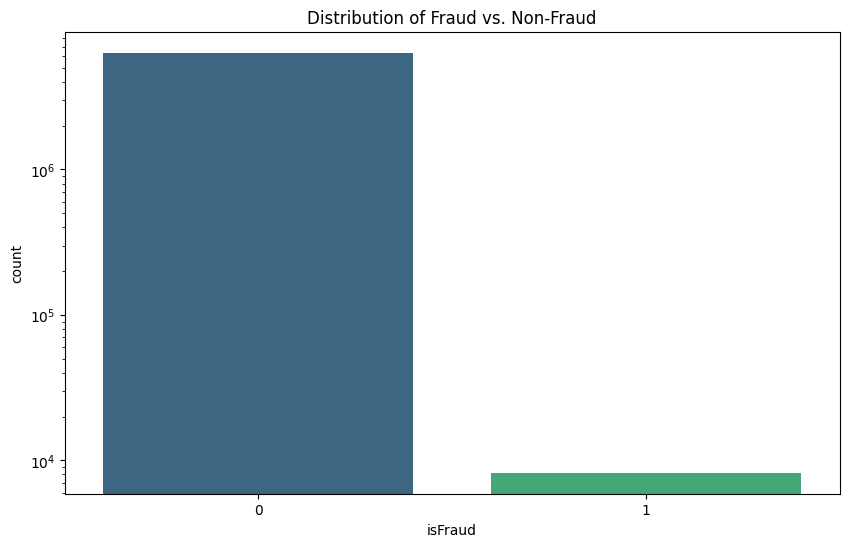

In [ ]:
# CELL 1: Setup & Target Variable Distribution
# WHAT THIS IS FOR: This chart visualizes the "Class Imbalance". It shows how rare fraud is
# compared to normal transactions. We use a log scale so the tiny amount of fraud is actually visible.
# This visually proves to your audience why you need to balance the dataset before training!

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='isFraud', data=paysim_data, palette='viridis', hue='isFraud', legend=False)
plt.title('Distribution of Fraud vs. Non-Fraud')
plt.yscale('log')
plt.show()

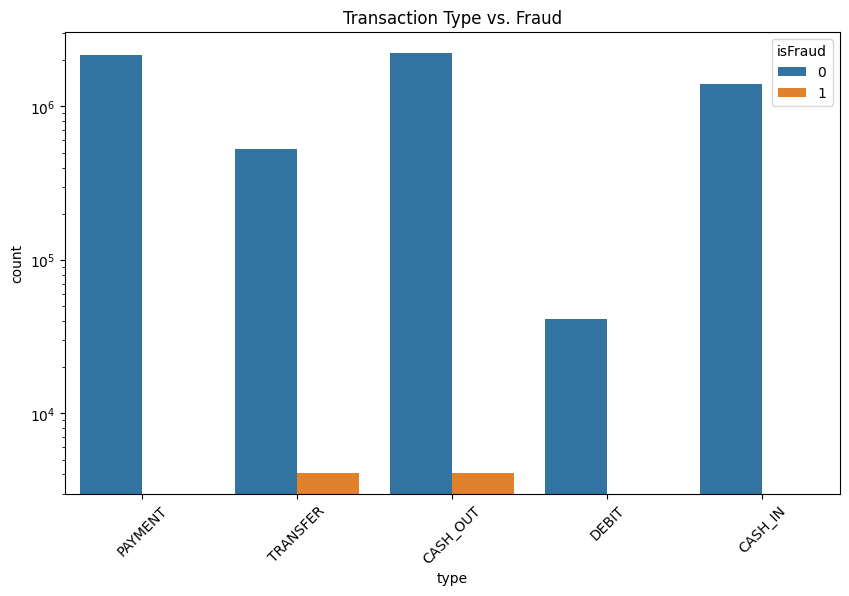

In [ ]:
# CELL 2: Transaction Type vs. Fraud
# WHAT THIS IS FOR: This chart breaks down the transactions by their type (PAYMENT, TRANSFER, etc.).
# It shows the model (and your audience) exactly which transaction types the fraudsters prefer to use.
# You will likely see fraud clustered almost entirely around TRANSFER and CASH_OUT.

plt.figure(figsize=(10, 6))
sns.countplot(x='type', hue='isFraud', data=paysim_data)
plt.title('Transaction Type vs. Fraud')
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()

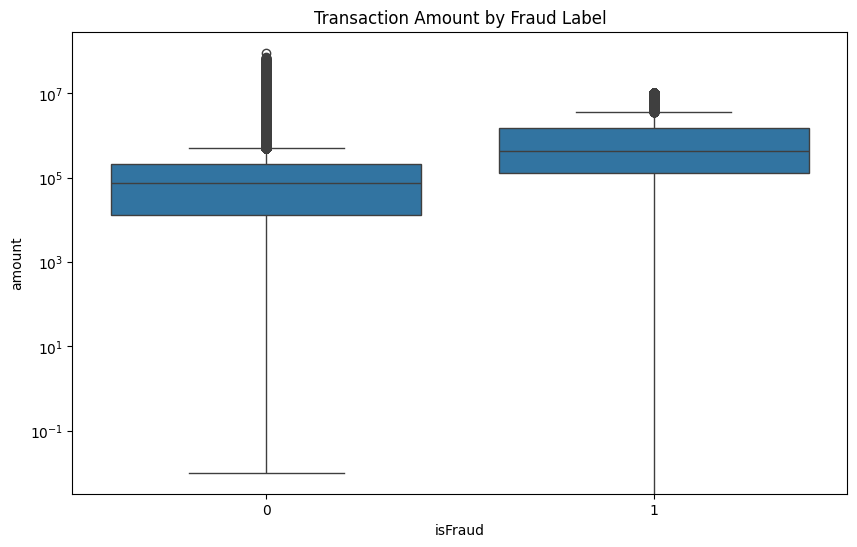

In [ ]:
# CELL 3: Transaction Amount Distribution
# WHAT THIS IS FOR: This boxplot compares the typical monetary 'amount' of a normal transaction
# versus a fraudulent one. Fraudsters often move money in massive bursts, and this chart helps
# visually explain if fraudulent transactions tend to involve much higher dollar amounts.

plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=paysim_data)
plt.title('Transaction Amount by Fraud Label')
plt.yscale('log')
plt.show()

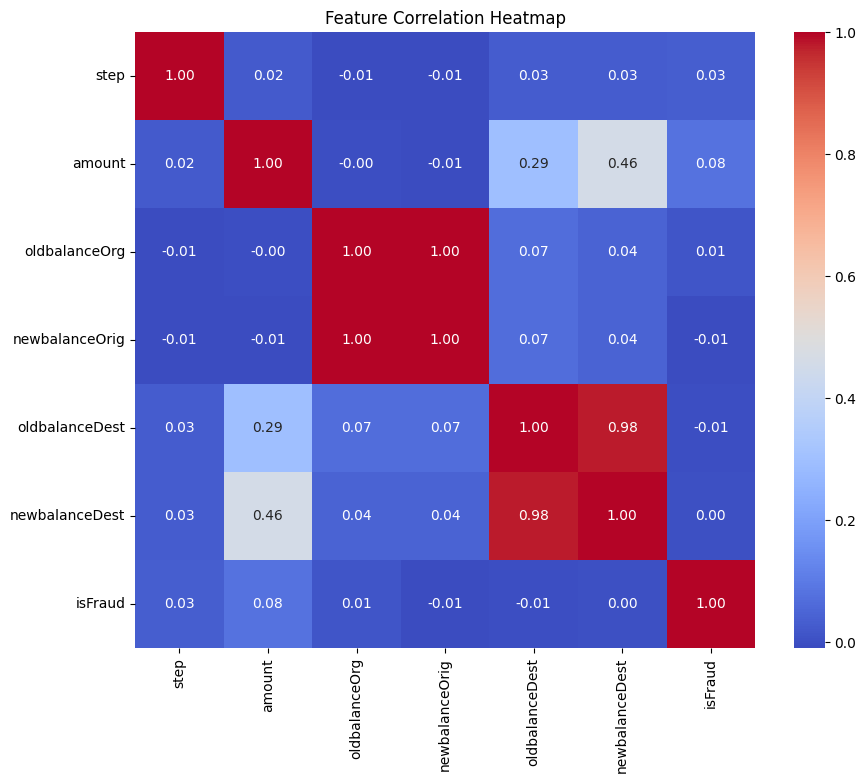

In [ ]:
# CELL 4: Feature Correlation Heatmap
# WHAT THIS IS FOR: This heatmap shows how mathematically related your numeric columns are to each other.
# For example, if 'amount' and 'newbalanceOrig' have a strong negative correlation, it means as the
# transfer amount goes up, the sender's balance predictably drops.

plt.figure(figsize=(10, 8))
# We only select the numeric columns for the math to work properly
correlation = paysim_data.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Data Transformation: One-Hot Encoding the 'type' column
# We use 'paysim_data' because it contains only the 5 correct PaySim types
# drop_first=True drops 'CASH_IN' to prevent multicollinearity
import pandas as pd

df_final = pd.get_dummies(paysim_data, columns=['type'], drop_first=True)

print("One-Hot Encoding Complete! (Scaling moved to after train/test split to prevent leakage)")
display(df_final.head())

One-Hot Encoding Complete! (Scaling moved to after train/test split to prevent leakage)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False


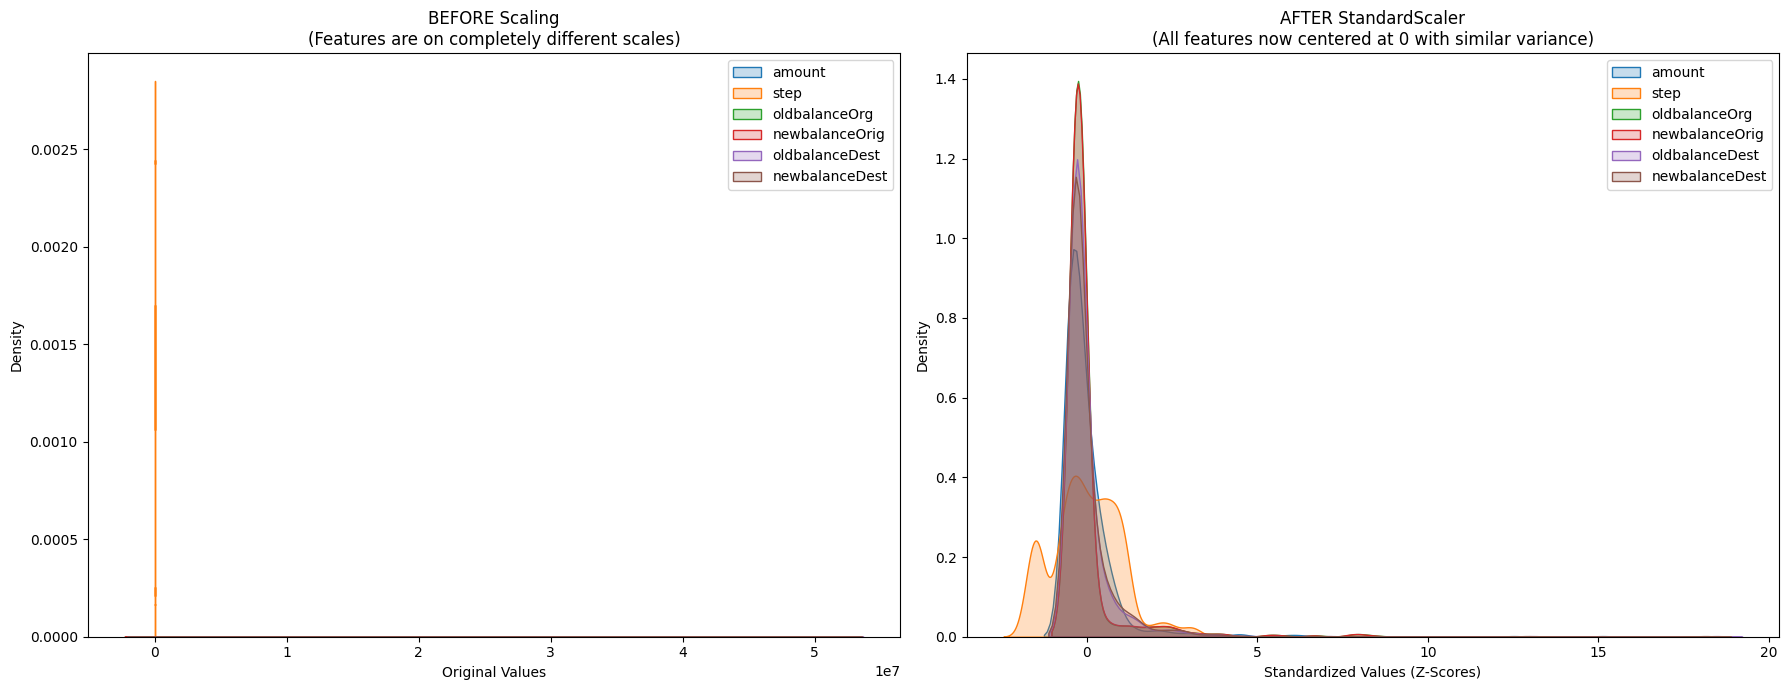

In [ ]:
# Visual Explanation of StandardScaler (All Features)
# This is a DEMO visualization only — the actual scaler used for training
# is fit exclusively on training data in the next cell to prevent data leakage.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Define the columns we want to scale
num_cols = ['amount', 'step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Take a sample for performance
sample_idx = paysim_data.sample(1000, random_state=42).index
before_sample = paysim_data.loc[sample_idx].copy()

# Apply a temporary scaler just for this visualization
temp_scaler = StandardScaler()
after_sample = before_sample.copy()
after_sample[num_cols] = temp_scaler.fit_transform(before_sample[num_cols])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. BEFORE SCALING (The "Messy" version)
for col in num_cols:
    sns.kdeplot(before_sample[col], ax=ax1, label=col, fill=True)
ax1.set_title('BEFORE Scaling\n(Features are on completely different scales)')
ax1.set_xlabel('Original Values')
ax1.legend(loc='upper right')

# 2. AFTER SCALING (The "Clean" version)
for col in num_cols:
    sns.kdeplot(after_sample[col], ax=ax2, label=col, fill=True)
ax2.set_title('AFTER StandardScaler\n(All features now centered at 0 with similar variance)')
ax2.set_xlabel('Standardized Values (Z-Scores)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

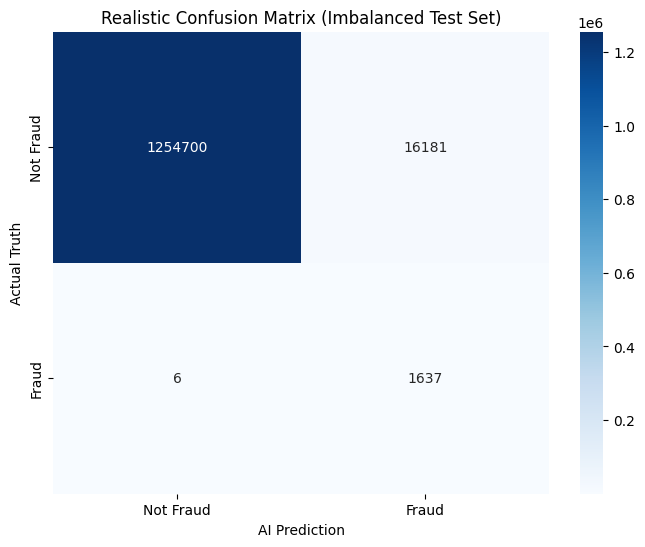


--- Realistic Performance Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.09      1.00      0.17      1643

    accuracy                           0.99   1272524
   macro avg       0.55      0.99      0.58   1272524
weighted avg       1.00      0.99      0.99   1272524



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. SPLIT FIRST (Preserves real-world 0.13% fraud imbalance in the test set)
X = df_final.drop('isFraud', axis=1)
y = df_final['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Prevent SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# 2. SCALE PROPERLY (Fit on Train, Transform Both to prevent Data Leakage)
scaler = StandardScaler()
num_cols = ['amount', 'step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 3. UNDERSAMPLE ONLY THE TRAINING SET
train_data = pd.concat([X_train, y_train], axis=1)
fraud_train = train_data[train_data['isFraud'] == 1]
normal_train = train_data[train_data['isFraud'] == 0]

# Balance the training set 50/50
normal_sample = normal_train.sample(n=len(fraud_train), random_state=42)
balanced_train = pd.concat([fraud_train, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_bal = balanced_train.drop('isFraud', axis=1)
y_train_bal = balanced_train['isFraud']

# 4. TRAIN AND EVALUATE ON REAL-WORLD DATA
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)
y_pred = rf_model.predict(X_test)

# 5. VISUALIZE THE REALISTIC RESULTS
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Realistic Confusion Matrix (Imbalanced Test Set)')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.show()

print("\n--- Realistic Performance Report ---")
print(classification_report(y_test, y_pred))

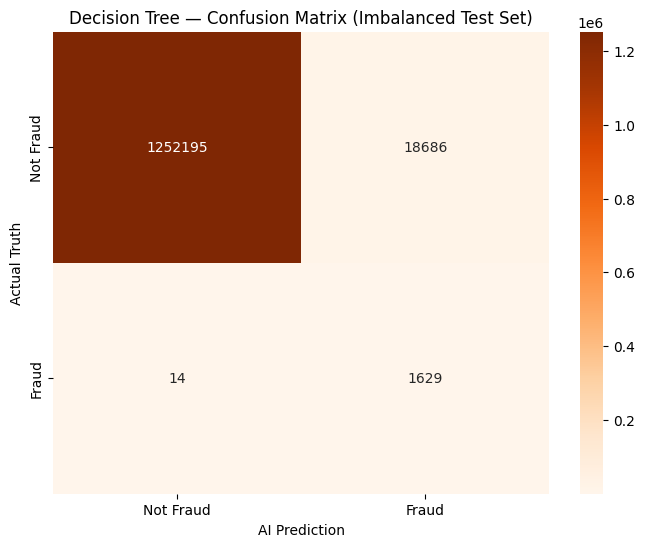


--- Decision Tree Performance Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270881
           1       0.08      0.99      0.15      1643

    accuracy                           0.99   1272524
   macro avg       0.54      0.99      0.57   1272524
weighted avg       1.00      0.99      0.99   1272524


======== MODEL COMPARISON ========


,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC
Model,,,,,
Random Forest,0.9873,0.0919,0.9963,0.1682,0.9995
Decision Tree,0.9853,0.0802,0.9915,0.1484,0.9922


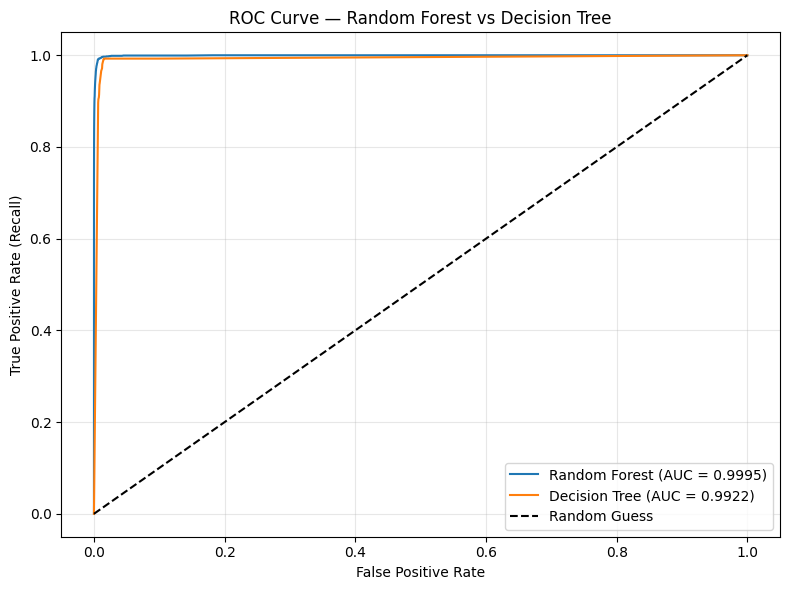

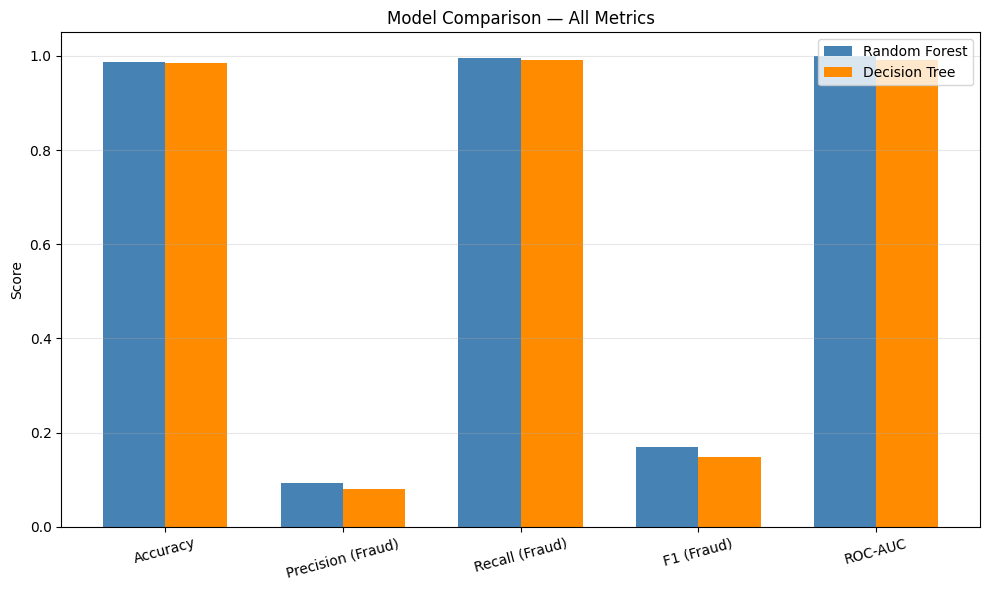


>>> BEST MODEL: Random Forest (highest F1-score for fraud detection)


In [ ]:
# ============================================================
# MODEL 2: Decision Tree + Side-by-Side Comparison with Random Forest
# ============================================================
# WHY DECISION TREE? It is the building block of Random Forest.
# Comparing the two shows how ensembling many weak trees into
# one forest improves accuracy, precision, and recall.
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------- 1. Train Decision Tree on the SAME balanced training set ----------
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_bal, y_train_bal)
y_pred_dt = dt_model.predict(X_test)

# ---------- 2. Confusion Matrix for Decision Tree ----------
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Decision Tree — Confusion Matrix (Imbalanced Test Set)')
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.show()

print("\n--- Decision Tree Performance Report ---")
print(classification_report(y_test, y_pred_dt))

# ---------- 3. Side-by-Side Metric Comparison ----------
models = {'Random Forest': (y_pred, rf_model),
          'Decision Tree': (y_pred_dt, dt_model)}

rows = []
for name, (preds, model) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision (Fraud)': precision_score(y_test, preds),
        'Recall (Fraud)':    recall_score(y_test, preds),
        'F1 (Fraud)':        f1_score(y_test, preds),
        'ROC-AUC':           roc_auc_score(y_test, proba)
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print("\n======== MODEL COMPARISON ========")
display(comparison_df.style.format('{:.4f}').highlight_max(axis=0, color='blue'))

# ---------- 4. ROC Curve Overlay ----------
plt.figure(figsize=(8, 6))
for name, (preds, model) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve — Random Forest vs Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 5. Bar Chart Comparison ----------
metrics_to_plot = ['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 'F1 (Fraud)', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, comparison_df.loc['Random Forest', metrics_to_plot], width,
       label='Random Forest', color='steelblue')
ax.bar(x + width/2, comparison_df.loc['Decision Tree', metrics_to_plot], width,
       label='Decision Tree', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 6. Final Verdict ----------
winner = comparison_df['F1 (Fraud)'].idxmax()
print(f"\n>>> BEST MODEL: {winner} (highest F1-score for fraud detection)")


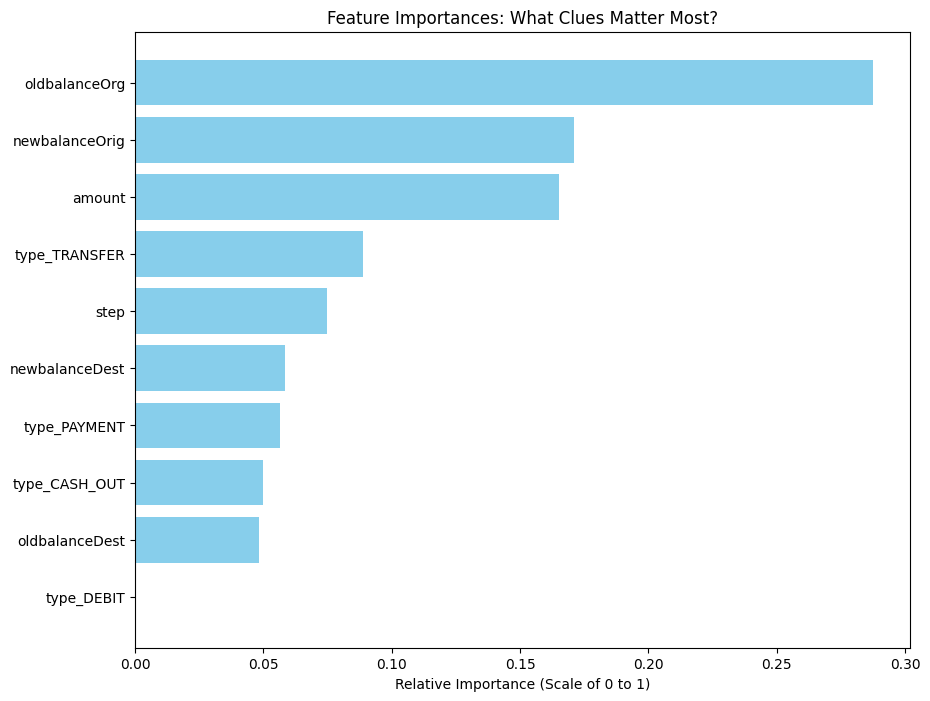

In [ ]:
# Feature Importance Visual
# WHAT THIS IS FOR: This chart ranks the features from "Most Important" to "Least Important".
# It answers the question: "What is the biggest red flag for fraud?"
# (Usually, it's the account balances or the transaction amount).

import numpy as np

# 1. Get the importance scores from our trained model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# 2. Plot the results
plt.figure(figsize=(10, 8))
plt.title('Feature Importances: What Clues Matter Most?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance (Scale of 0 to 1)')
plt.show()

In [ ]:
# AI Audit - One Fraud vs One Normal
# WHAT THIS IS FOR: This "drills down" into two specific examples.
# It shows the raw data for one criminal and one honest user,
# and then shows you what the AI predicted for each.

import pandas as pd

# 1. Find indices for one Fraud and one Normal transaction in our test set
fraud_idx = y_test[y_test == 1].index[0]
normal_idx = y_test[y_test == 0].index[0]

# 2. Extract these two rows
samples = X_test.loc[[normal_idx, fraud_idx]]
actual_labels = y_test.loc[[normal_idx, fraud_idx]]

# 3. Let the AI predict just these two
predictions = rf_model.predict(samples)

# 4. Create a readable display
audit_df = samples.copy()
audit_df['Actual Truth'] = actual_labels.map({1: 'FRAUD', 0: 'NORMAL'})
audit_df['AI Prediction'] = pd.Series(predictions, index=samples.index).map({1: 'FRAUD', 0: 'NORMAL'})

# 5. Convert numeric columns back to real dollars for your report
# (This makes it easier for humans to read than -0.29...)
num_cols = ['amount', 'step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
audit_df[num_cols] = scaler.inverse_transform(audit_df[num_cols])

print("--- AI Audit: Checking the Results ---")
display(audit_df.T) # Transposed for easier reading

--- AI Audit: Checking the Results ---


,4051353,6202693
step,300.0,583.0
amount,890577.21,759701.03
oldbalanceOrg,218.0,759701.03
newbalanceOrig,-0.0,-0.0
oldbalanceDest,0.0,1076095.67
newbalanceDest,890577.21,1835796.71
type_CASH_OUT,False,True
type_DEBIT,False,False
type_PAYMENT,False,False
type_TRANSFER,True,False
